# Step 4: Patch-based Transformer Encoder

**Goal:** Train a transformer model on source domain to predict final penicillin concentration from early batch signals.

**Contents:**
1. Data Setup & Splits
2. Model Architecture Explanation
3. Training Configuration
4. Training & Validation
5. Results Visualization
6. Comparison with Baselines

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import torch.nn as nn

from src.data_loader import load_batches
from src.domain_splits import get_control_mode_split
from src.dataset import create_dataloaders, IndPenSimDataset
from src.feature_config import INPUT_FEATURES_EXPANDED
from src.preprocessing import extract_early_window
from src.transformer_model import (
    PatchTSTRegressor, 
    create_model, 
    count_parameters,
    PatchEmbedding,
)
from src.train import train_and_evaluate, evaluate

sns.set_theme(style='whitegrid')
%matplotlib inline

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Using {len(INPUT_FEATURES_EXPANDED)} input features")

Using device: cpu
Using 25 input features


## 1. Data Setup & Splits

### Domain Split Strategy
- **Source Domain:** Recipe-driven batches (1-30) - used for training and validation
- **Target Domain:** APC/Raman-based batches (61-90) - used for final evaluation
- **Validation Split:** 20% of source domain held out for early stopping

### Data Leakage Prevention
- Normalization statistics computed only from training set
- Early stopping based on source validation, not target

In [2]:
# Load batches
batches = load_batches()
print(f"Loaded {len(batches)} batches")

# Get domain split (1b: Recipe vs APC)
split = get_control_mode_split("1c")
source_ids = split["source"]
target_ids = split["target"]

print(f"\nDomain Split (variant):")
print(f"  Source: Batches {min(source_ids)}-{max(source_ids)} ({len(source_ids)} batches)")
print(f"  Target: Batches {min(target_ids)}-{max(target_ids)} ({len(target_ids)} batches)")

Loaded 100 batches

Domain Split (variant):
  Source: Batches 1-60 (60 batches)
  Target: Batches 61-90 (30 batches)


In [3]:
# Create DataLoaders
BATCH_SIZE = 12
WINDOW_FRACTION = 0.9

data = create_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=BATCH_SIZE,
    window_fraction=WINDOW_FRACTION,
    seed=42,
)

print(f"\nDataLoader Configuration:")
print(f"  Sequence length: {data['target_len']} time steps")
print(f"  Number of features: {data['n_features']}")
print(f"  Features used: {data['stats']['features']}")

# Verification
assert data['n_features'] == 25, f"Expected 25 features, got {data['n_features']}"

print(f"\nSplit sizes:")
print(f"  Train: {len(data['train'].dataset)} batches")
print(f"  Val:   {len(data['val'].dataset)} batches")
print(f"  Target: {len(data['target'].dataset)} batches")


DataLoader Configuration:
  Sequence length: 1035 time steps
  Number of features: 25
  Features used: ['Fg', 'Fs', 'Fw', 'pressure', 'Fpaa', 'Foil', 'Fa', 'Fh', 'Fremoved', 'Fb', 'Fc', 'S', 'OUR', 'O2', 'pH', 'T', 'DO2', 'V', 'Wt', 'CO2outgas', 'CER', 'PAA_offline', 'NH3_offline', 'X_offline', 'Viscosity_offline']

Split sizes:
  Train: 48 batches
  Val:   12 batches
  Target: 30 batches


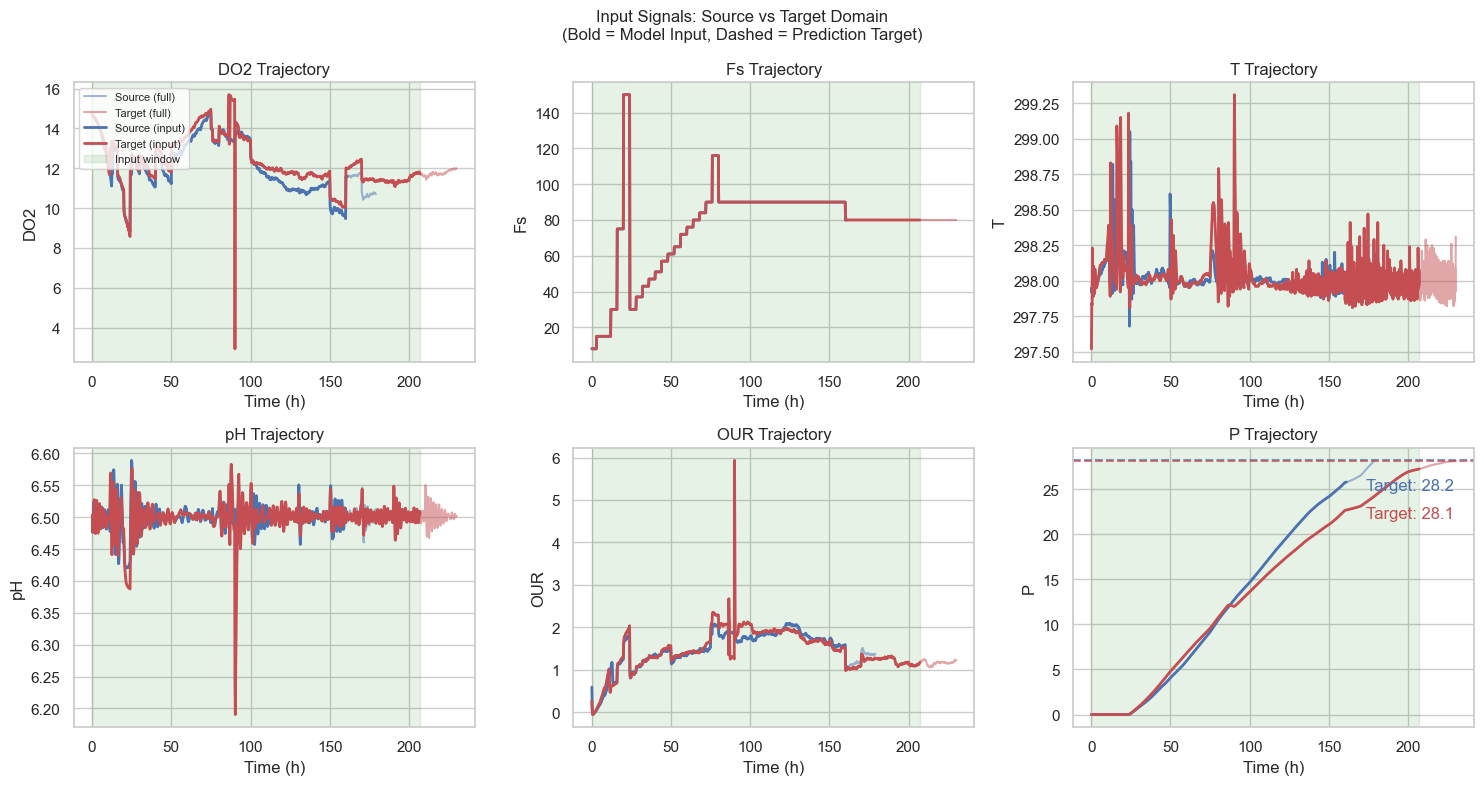

In [4]:
# Visualize example input data
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Get one batch from each domain for visualization
sample_source = batches[5]  # Example source batch
sample_target = batches[70]  # Example target batch

features_to_plot = ['DO2', 'Fs', 'T', 'pH', 'OUR', 'P']

for idx, feat in enumerate(features_to_plot):
    ax = axes.flatten()[idx]
    
    # Plot full trajectory
    ax.plot(sample_source['time'], sample_source[feat], 'b-', alpha=0.5, label='Source (full)')
    ax.plot(sample_target['time'], sample_target[feat], 'r-', alpha=0.5, label='Target (full)')
    
    # Highlight early window (25%)
    source_early = extract_early_window(sample_source, WINDOW_FRACTION)
    target_early = extract_early_window(sample_target, WINDOW_FRACTION)
    
    ax.plot(source_early['time'], source_early[feat], 'b-', linewidth=2, label='Source (input)')
    ax.plot(target_early['time'], target_early[feat], 'r-', linewidth=2, label='Target (input)')
    
    # Mark prediction target (final P)
    if feat == 'P':
        ax.axhline(sample_source['P'].iloc[-1], color='b', linestyle='--', alpha=0.7)
        ax.axhline(sample_target['P'].iloc[-1], color='r', linestyle='--', alpha=0.7)
        ax.annotate(f'Target: {sample_source["P"].iloc[-1]:.1f}', 
                    xy=(0.95, 0.85), xycoords='axes fraction', ha='right', color='b')
        ax.annotate(f'Target: {sample_target["P"].iloc[-1]:.1f}', 
                    xy=(0.95, 0.75), xycoords='axes fraction', ha='right', color='r')
    
    ax.set_xlabel('Time (h)')
    ax.set_ylabel(feat)
    ax.set_title(f'{feat} Trajectory')
    
    # Shade early window region
    max_time = max(sample_source['time'].max(), sample_target['time'].max())
    ax.axvspan(0, max_time * WINDOW_FRACTION, alpha=0.1, color='green', label='Input window')

axes[0, 0].legend(loc='upper left', fontsize=8)
plt.suptitle('Input Signals: Source vs Target Domain\n(Bold = Model Input, Dashed = Prediction Target)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/transformer_input_signals.png', dpi=150)
plt.show()

## 2. Model Architecture

### PatchTST Architecture

The model follows a patch-based transformer design inspired by PatchTST:

```
Input (B, T, C) → Patch Embed → Positional Encoding → Transformer Encoder → Mean Pool → MLP → y_hat
```

**Key Components:**
1. **Patch Embedding**: Divides time-series into overlapping patches, projects to d_model
2. **Positional Encoding**: Sinusoidal encoding for patch position
3. **Transformer Encoder**: Multi-head self-attention + FFN layers
4. **Pooling**: Mean pooling over patches
5. **Regression Head**: MLP for final prediction

In [5]:
# Model configuration
MODEL_CONFIG = {
    'patch_len': 32,      # Length of each patch
    'patch_stride': 16,    # Stride between patches (50% overlap)
    'd_model': 32,       # Transformer embedding dimension
    'n_heads': 8,        # Number of attention heads
    'n_layers': 3,        # Number of transformer layers
    'd_ff': 32,           # Feed-forward dimension
    'dropout': 0.1,       # Dropout rate
    'pool': 'mean',       # Pooling method
    'head_hidden': 8,   # Regression head hidden dim
}

print("Model Configuration:")
for k, v in MODEL_CONFIG.items():
    print(f"  {k}: {v}")

Model Configuration:
  patch_len: 32
  patch_stride: 16
  d_model: 32
  n_heads: 8
  n_layers: 3
  d_ff: 32
  dropout: 0.1
  pool: mean
  head_hidden: 8


In [6]:
# Create model
model = create_model(
    n_features=data['n_features'],
    seq_len=data['target_len'],
    config=MODEL_CONFIG,
)

n_params = count_parameters(model)
print(f"\nModel created: PatchTSTRegressor")
print(f"  Total parameters: {n_params:,}")
print(f"  Trainable parameters: {n_params:,}")


Model created: PatchTSTRegressor
  Total parameters: 45,361
  Trainable parameters: 45,361


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



Patch Configuration:
  Input sequence length: 1035
  Patch length: 32
  Patch stride: 16
  Number of patches: 63
  Overlap: 16 time steps


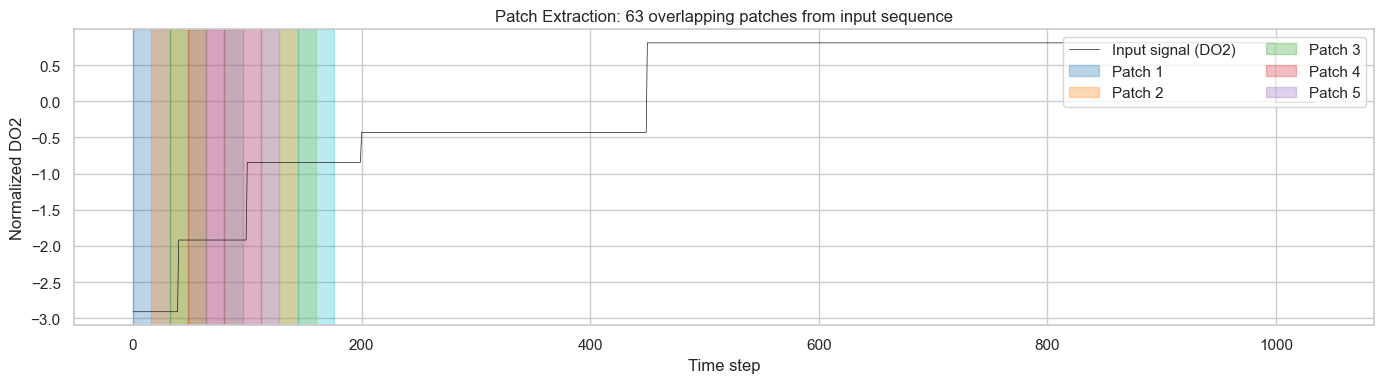

In [7]:
# Visualize patch creation
patch_embed = PatchEmbedding(
    n_features=data['n_features'],
    patch_len=MODEL_CONFIG['patch_len'],
    patch_stride=MODEL_CONFIG['patch_stride'],
    d_model=MODEL_CONFIG['d_model'],
)

n_patches = patch_embed.get_num_patches(data['target_len'])
print(f"\nPatch Configuration:")
print(f"  Input sequence length: {data['target_len']}")
print(f"  Patch length: {MODEL_CONFIG['patch_len']}")
print(f"  Patch stride: {MODEL_CONFIG['patch_stride']}")
print(f"  Number of patches: {n_patches}")
print(f"  Overlap: {MODEL_CONFIG['patch_len'] - MODEL_CONFIG['patch_stride']} time steps")

# Visualize how patches cover the input
fig, ax = plt.subplots(figsize=(14, 4))

# Plot input signal (example feature)
X_sample, y_sample, _ = data['train'].dataset[0]
ax.plot(X_sample[:, 0].numpy(), 'k-', linewidth=0.5, label='Input signal (DO2)')

# Highlight patches
colors = plt.cm.tab10(np.linspace(0, 1, min(n_patches, 10)))
for i in range(min(n_patches, 10)):  # Show first 10 patches
    start = i * MODEL_CONFIG['patch_stride']
    end = start + MODEL_CONFIG['patch_len']
    ax.axvspan(start, end, alpha=0.3, color=colors[i], label=f'Patch {i+1}' if i < 5 else None)

ax.set_xlabel('Time step')
ax.set_ylabel('Normalized DO2')
ax.set_title(f'Patch Extraction: {n_patches} overlapping patches from input sequence')
ax.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig('../outputs/figures/transformer_patches.png', dpi=150)
plt.show()

## 3. Training Configuration

**Training Strategy:**
- **Optimizer:** AdamW with weight decay for regularization
- **Scheduler:** Cosine annealing learning rate
- **Loss:** MSE (Mean Squared Error)
- **Early Stopping:** Based on validation loss (patience)
- **Validation:** Source domain held-out set (no target domain leakage)

In [8]:
# Training configuration
TRAIN_CONFIG = {
    'n_epochs': 1000,
    'lr': 1e-5,
    'weight_decay': 1e-4,
    'patience': 50,
}

print("Training Configuration:")
for k, v in TRAIN_CONFIG.items():
    print(f"  {k}: {v}")

Training Configuration:
  n_epochs: 1000
  lr: 1e-05
  weight_decay: 0.0001
  patience: 50


## 4. Training & Validation

In [9]:
for ins, out, _ in data['train']:
    print(ins.shape, out)
    break

torch.Size([12, 1035, 25]) tensor([0.6083, 0.5889, 0.7063, 0.6020, 0.5883, 0.2534, 0.6425, 0.6503, 0.1937,
        0.6214, 0.5660, 0.6710])


In [10]:
print(ins[-1,])

tensor([[-2.9099, -2.5534, -0.9100,  ..., -0.5181, -2.7163, -1.9849],
        [-2.9099, -2.5534, -0.9100,  ..., -0.5181, -2.7163, -1.9849],
        [-2.9099, -2.5534, -0.9100,  ..., -0.5181, -2.7163, -1.9849],
        ...,
        [-0.0196,  1.0460,  0.6434,  ..., -0.1444,  0.6824,  1.2782],
        [-0.0196,  1.0460,  0.6434,  ..., -0.1379,  0.6809,  1.2750],
        [-0.0196,  1.0460,  0.6434,  ..., -0.1314,  0.6794,  1.2718]])


In [11]:
# Train model
print("Starting training...\n")

results = train_and_evaluate(
    model=model,
    train_loader=data['train'],
    val_loader=data['val'],
    target_loader=data['target'],
    device=device,
    verbose=True,
    **TRAIN_CONFIG,
)

Starting training...

Epoch 10/1000 | Train Loss: 0.0328 | Val Loss: 0.0329 | Val MAE: 0.146
Epoch 20/1000 | Train Loss: 0.0278 | Val Loss: 0.0325 | Val MAE: 0.155
Epoch 30/1000 | Train Loss: 0.0233 | Val Loss: 0.0321 | Val MAE: 0.158
Epoch 40/1000 | Train Loss: 0.0225 | Val Loss: 0.0302 | Val MAE: 0.155
Epoch 50/1000 | Train Loss: 0.0247 | Val Loss: 0.0276 | Val MAE: 0.149
Epoch 60/1000 | Train Loss: 0.0203 | Val Loss: 0.0254 | Val MAE: 0.143
Epoch 70/1000 | Train Loss: 0.0138 | Val Loss: 0.0229 | Val MAE: 0.136
Epoch 80/1000 | Train Loss: 0.0144 | Val Loss: 0.0207 | Val MAE: 0.130
Epoch 90/1000 | Train Loss: 0.0125 | Val Loss: 0.0184 | Val MAE: 0.122
Epoch 100/1000 | Train Loss: 0.0182 | Val Loss: 0.0168 | Val MAE: 0.117
Epoch 110/1000 | Train Loss: 0.0179 | Val Loss: 0.0146 | Val MAE: 0.108
Epoch 120/1000 | Train Loss: 0.0113 | Val Loss: 0.0133 | Val MAE: 0.102
Epoch 130/1000 | Train Loss: 0.0093 | Val Loss: 0.0119 | Val MAE: 0.096
Epoch 140/1000 | Train Loss: 0.0085 | Val Loss: 0.0

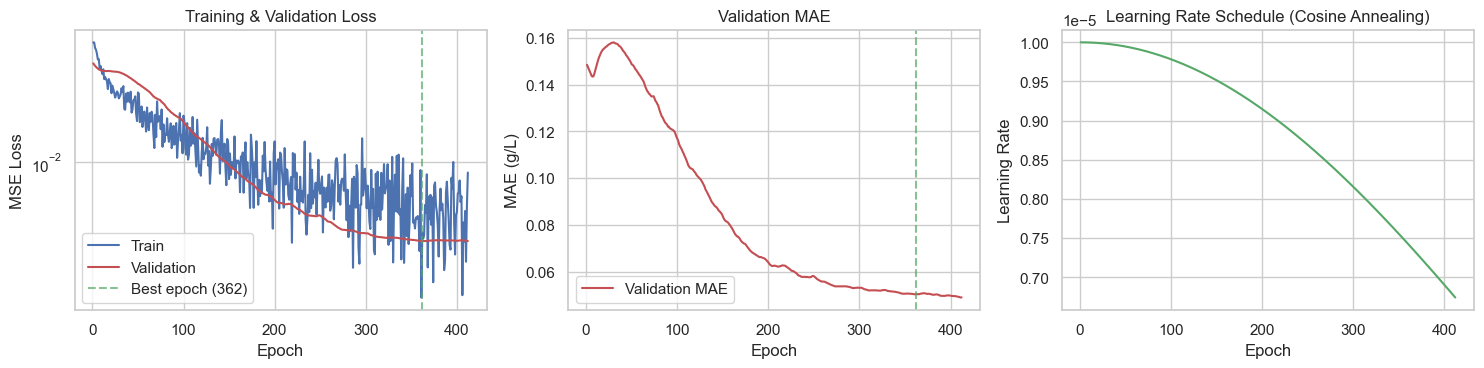

In [12]:
# Plot training curves
history = results['history']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
ax = axes[0]
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], 'b-', label='Train')
ax.plot(epochs, history['val_loss'], 'r-', label='Validation')
ax.axvline(results['best_epoch'], color='g', linestyle='--', alpha=0.7, label=f'Best epoch ({results["best_epoch"]})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.set_yscale('log')

# MAE curve
ax = axes[1]
ax.plot(epochs, history['val_mae'], 'r-', label='Validation MAE')
ax.axvline(results['best_epoch'], color='g', linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (g/L)')
ax.set_title('Validation MAE')
ax.legend()

# Learning rate
ax = axes[2]
ax.plot(epochs, history['lr'], 'g-')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule (Cosine Annealing)')

plt.tight_layout()
plt.savefig('../outputs/figures/transformer_training_curves.png', dpi=150)
plt.show()

### Predicted vs Actual Values

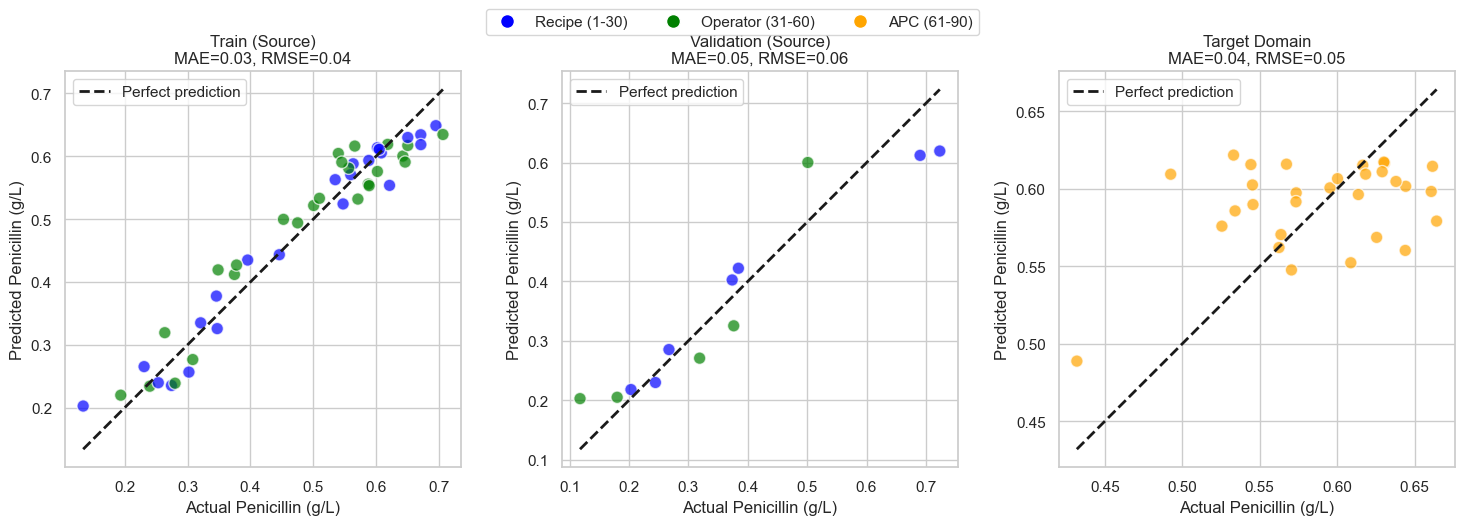

In [13]:
# Extract predictions and targets
train_preds = results['train_metrics']['predictions']
train_targets = results['train_metrics']['targets']
val_preds = results['val_metrics']['predictions']
val_targets = results['val_metrics']['targets']
target_preds = results['target_metrics']['predictions']
target_targets = results['target_metrics']['targets']

# Get batch IDs from each dataset
train_batch_ids = data['train'].dataset.batch_ids
val_batch_ids = data['val'].dataset.batch_ids
target_batch_ids = data['target'].dataset.batch_ids

# Define batch type colors
BATCH_TYPE_COLORS = {
    'Recipe': 'blue',
    'Operator': 'green', 
    'APC': 'orange',
}

def get_batch_type(batch_id):
    """Map batch ID to control mode type."""
    if 1 <= batch_id <= 30:
        return 'Recipe'
    elif 31 <= batch_id <= 60:
        return 'Operator'
    elif 61 <= batch_id <= 90:
        return 'APC'
    else:
        return 'Unknown'

def get_colors_for_batches(batch_ids):
    """Get color array for a list of batch IDs."""
    return [BATCH_TYPE_COLORS[get_batch_type(bid)] for bid in batch_ids]

# Plot predictions vs actuals
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [
    ('Train (Source)', train_preds, train_targets, train_batch_ids),
    ('Validation (Source)', val_preds, val_targets, val_batch_ids),
    ('Target Domain', target_preds, target_targets, target_batch_ids),
]

for ax, (title, preds, targets, batch_ids) in zip(axes, splits):
    colors = get_colors_for_batches(batch_ids)
    ax.scatter(targets, preds, alpha=0.7, c=colors, edgecolor='white', s=80)
    
    # Perfect prediction line
    min_val = min(targets.min(), preds.min())
    max_val = max(targets.max(), preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect prediction')
    
    # Compute metrics
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets)**2))
    
    ax.set_xlabel('Actual Penicillin (g/L)')
    ax.set_ylabel('Predicted Penicillin (g/L)')
    ax.set_title(f'{title}\nMAE={mae:.2f}, RMSE={rmse:.2f}')
    ax.legend()
    ax.set_aspect('equal')

# Add legend for batch types (on first subplot)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Recipe (1-30)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Operator (31-60)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='APC (61-90)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig('../outputs/figures/transformer_predictions.png', dpi=150)
plt.show()

## Quickfit

In [14]:
# Recreate data with fresh module
data = create_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=BATCH_SIZE,
    window_fraction=WINDOW_FRACTION,
    seed=42,
)
print(f"Stats: y_min={data['stats']['y_min']}, y_max={data['stats']['y_max']}")
print(f"Number of features: {data['n_features']}")
assert data['n_features'] == 25, f"Expected 25 features, got {data['n_features']}"

# Reset seeds and create fresh model
torch.manual_seed(1256)
np.random.seed(4789)

model = create_model(
    n_features=data['n_features'],
    seq_len=data['target_len'],
    config=MODEL_CONFIG,
)

# Train with stats
print("\nTraining transformer...")
results = train_and_evaluate(
    model=model,
    train_loader=data['train'],
    val_loader=data['val'],
    target_loader=data['target'],
    device=device,
    verbose=False,
    stats=data['stats'],
    **TRAIN_CONFIG,
)

print(f"\n=== Results (should be in g/L) ===")
print(f"Train predictions: [{results['train_metrics']['predictions'].min():.2f}, {results['train_metrics']['predictions'].max():.2f}]")
print(f"Train targets: [{results['train_metrics']['targets'].min():.2f}, {results['train_metrics']['targets'].max():.2f}]")
print(f"Train MAE: {results['train_metrics']['mae']:.2f} g/L")
print(f"Val MAE: {results['val_metrics']['mae']:.2f} g/L")
print(f"Target MAE: {results['target_metrics']['mae']:.2f} g/L")

Stats: y_min=0.0, y_max=50.0
Number of features: 25

Training transformer...


/Users/aless/Desktop/Projects/IndPenSim_Forecast_UDA/notebooks/../src/transformer_model.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)



=== Results (should be in g/L) ===
Train predictions: [6.98, 34.71]
Train targets: [6.70, 35.32]
Train MAE: 1.50 g/L
Val MAE: 2.27 g/L
Target MAE: 2.53 g/L


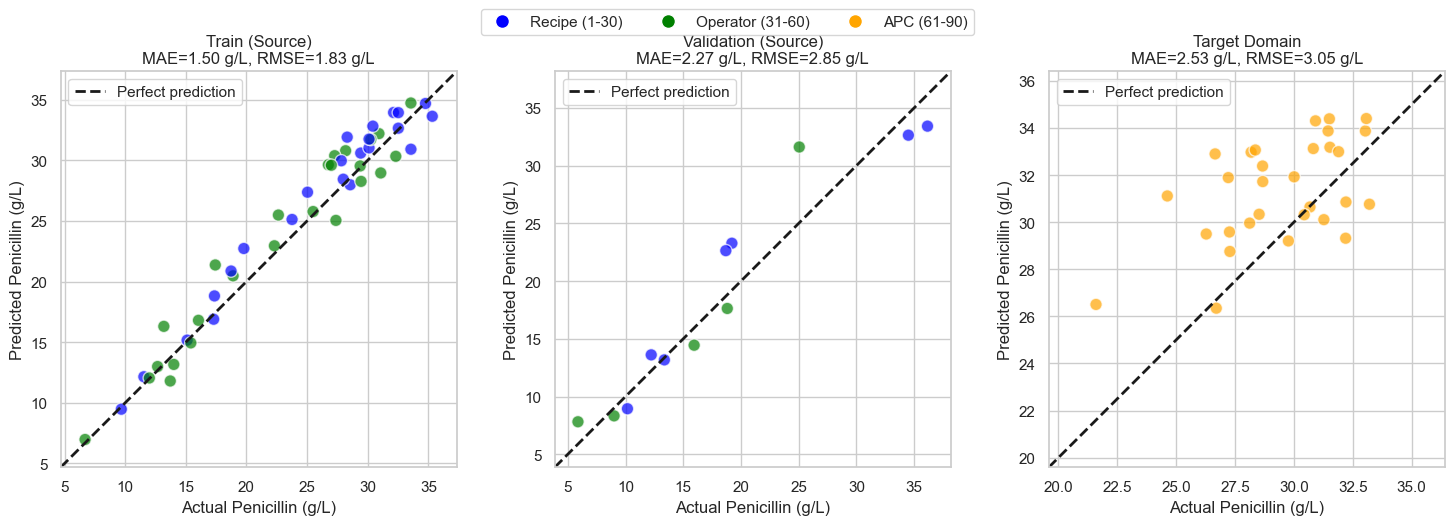


Plot shows actual penicillin concentration in g/L (not normalized)
Train: MAE=1.50 g/L, RMSE=1.83 g/L
Val:   MAE=2.27 g/L, RMSE=2.85 g/L
Target: MAE=2.53 g/L, RMSE=3.05 g/L


In [15]:
# Create the transformer predictions plot with actual concentration values
train_preds = results['train_metrics']['predictions']
train_targets = results['train_metrics']['targets']
val_preds = results['val_metrics']['predictions']
val_targets = results['val_metrics']['targets']
target_preds = results['target_metrics']['predictions']
target_targets = results['target_metrics']['targets']

# Get batch IDs for coloring
train_batch_ids = data['train'].dataset.batch_ids
val_batch_ids = data['val'].dataset.batch_ids
target_batch_ids = data['target'].dataset.batch_ids

# Batch type colors
BATCH_TYPE_COLORS = {'Recipe': 'blue', 'Operator': 'green', 'APC': 'orange'}

def get_batch_type(bid):
    if 1 <= bid <= 30: return 'Recipe'
    elif 31 <= bid <= 60: return 'Operator'
    else: return 'APC'

def get_colors(batch_ids):
    return [BATCH_TYPE_COLORS[get_batch_type(bid)] for bid in batch_ids]

# Create plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits = [
    ('Train (Source)', train_preds, train_targets, train_batch_ids),
    ('Validation (Source)', val_preds, val_targets, val_batch_ids),
    ('Target Domain', target_preds, target_targets, target_batch_ids),
]

for ax, (title, preds, targets, batch_ids) in zip(axes, splits):
    colors = get_colors(batch_ids)
    ax.scatter(targets, preds, alpha=0.7, c=colors, edgecolor='white', s=80)
    
    # Perfect prediction line
    all_vals = np.concatenate([targets, preds])
    min_val, max_val = all_vals.min() - 2, all_vals.max() + 2
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect prediction')
    
    # Compute metrics
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets)**2))
    
    ax.set_xlabel('Actual Penicillin (g/L)')
    ax.set_ylabel('Predicted Penicillin (g/L)')
    ax.set_title(f'{title}\nMAE={mae:.2f} g/L, RMSE={rmse:.2f} g/L')
    ax.legend(loc='upper left')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal')

# Add batch type legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Recipe (1-30)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Operator (31-60)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='APC (61-90)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig('../outputs/figures/transformer_predictions.png', dpi=150)
plt.show()

print("\nPlot shows actual penicillin concentration in g/L (not normalized)")
print(f"Train: MAE={results['train_metrics']['mae']:.2f} g/L, RMSE={results['train_metrics']['rmse']:.2f} g/L")
print(f"Val:   MAE={results['val_metrics']['mae']:.2f} g/L, RMSE={results['val_metrics']['rmse']:.2f} g/L")
print(f"Target: MAE={results['target_metrics']['mae']:.2f} g/L, RMSE={results['target_metrics']['rmse']:.2f} g/L")

In [16]:
# Save model checkpoint for use in step4b_domain_shift
import os
os.makedirs('../outputs/models', exist_ok=True)

checkpoint = {
    'n_features': data['n_features'],
    'seq_len': data['target_len'],
    'model_config': MODEL_CONFIG,
    'model_state_dict': model.state_dict(),
    'results': {
        'train_mae': results['train_metrics']['mae'],
        'val_mae': results['val_metrics']['mae'],
        'target_mae': results['target_metrics']['mae'],
    },
    'window_fraction': WINDOW_FRACTION,
}

model_path = '../outputs/models/transformer_baseline.pt'
torch.save(checkpoint, model_path)
print(f"Saved model checkpoint to {model_path}")

Saved model checkpoint to ../outputs/models/transformer_baseline.pt


### Domain Shift Analysis

/var/folders/s3/fkdq7lzx1bvdt4sqbz1dsg0c0000gp/T/ipykernel_1373/2830498782.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([source_errors, target_errors], labels=['Source Domain', 'Target Domain'])


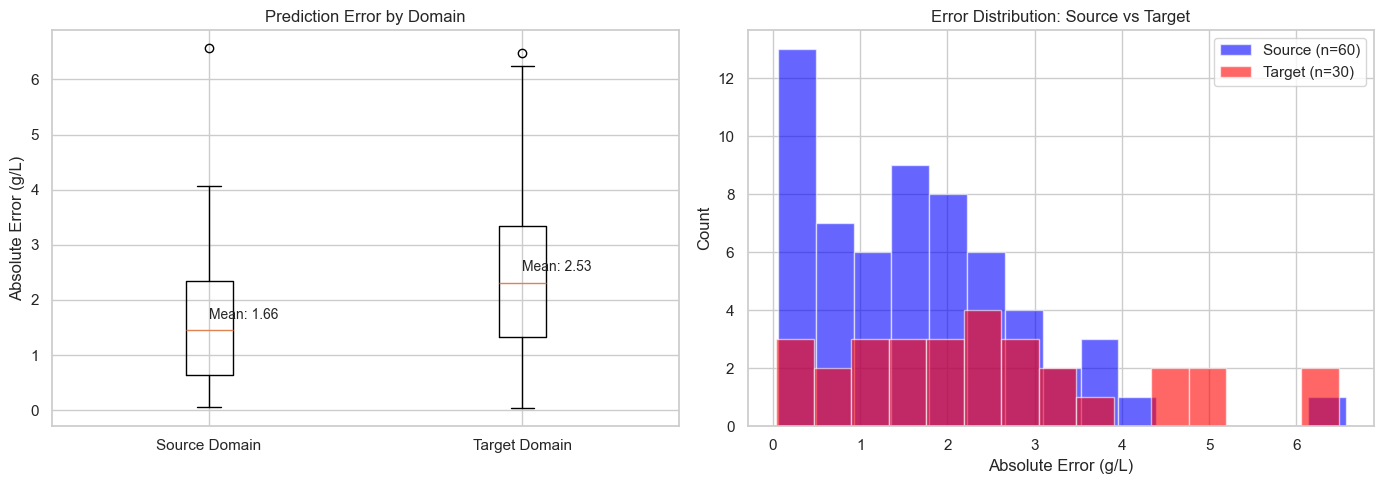

In [17]:
# Visualize domain shift in predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error by domain
ax = axes[0]
source_errors = np.abs(np.concatenate([train_preds - train_targets, val_preds - val_targets]))
target_errors = np.abs(target_preds - target_targets)

ax.boxplot([source_errors, target_errors], labels=['Source Domain', 'Target Domain'])
ax.set_ylabel('Absolute Error (g/L)')
ax.set_title('Prediction Error by Domain')

# Add mean annotations
ax.annotate(f'Mean: {source_errors.mean():.2f}', xy=(1, source_errors.mean()), fontsize=10)
ax.annotate(f'Mean: {target_errors.mean():.2f}', xy=(2, target_errors.mean()), fontsize=10)

# Error distribution comparison
ax = axes[1]
ax.hist(source_errors, bins=15, alpha=0.6, label=f'Source (n={len(source_errors)})', color='blue')
ax.hist(target_errors, bins=15, alpha=0.6, label=f'Target (n={len(target_errors)})', color='red')
ax.set_xlabel('Absolute Error (g/L)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution: Source vs Target')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/transformer_domain_shift.png', dpi=150)
plt.show()